# 1.8) Statistical Foundations and the Machine-Learning Stepping-Stone

This closing subchapter connects descriptive statistics to a first supervised model. Using an environmental lapse rate — air temperature as a function of elevation — it moves from exploratory plots, histograms, and correlation, through the scikit-learn estimator interface (instantiate, fit, predict), to an honest evaluation on held-out data with RMSE and the coefficient of determination. It then turns to unsupervised learning on a real dataset — k-means clustering and PCA on Palmer Archipelago penguin measurements — before the generated-code bug. The estimator-as-object pattern is the one introduced in the object-oriented subchapter. At the end, the generated code judges a model by how well it fits the data it was trained on: a near-perfect score on the training set, and a badly wrong prediction on new points.

:::{admonition} **Learning objectives**
:class: tip
- Explore data with seaborn (a layer over matplotlib), and summarise it with descriptive statistics and correlation.
- Visualise a distribution with a histogram and a KDE, split by category with `hue=`, and compare two variables at once with `jointplot`.
- Use the scikit-learn estimator interface: instantiate, fit, predict, with the X/y convention.
- Split data into train and test sets, and fit a linear regression for the lapse rate.
- Evaluate with RMSE and R^2, and recognise overfitting.
- Scale features and chain steps with a Pipeline.
- Fit a linear classifier (`LogisticRegression`) for a categorical target.
- Group unlabelled observations with `KMeans`, choosing k with the elbow method, and summarise correlated features with `PCA`.
:::

## Exploratory Data Analysis with seaborn

seaborn draws statistical graphics directly from a dataframe. We generate a synthetic set of stations whose temperature falls with elevation at roughly the environmental lapse rate of −6.5 °C km⁻¹, plus noise, and add a loosely elevation-dependent count of snow days.

seaborn is not a replacement for matplotlib but a layer on top of it: pass column names instead of extracted arrays, and get a sensible default style, a legend, and — for `regplot` below — a fitted trend line, all in one call. `ax=` still accepts a matplotlib axes, so the two compose rather than compete; reach for matplotlib directly whenever a plot needs more control than seaborn's defaults give you.

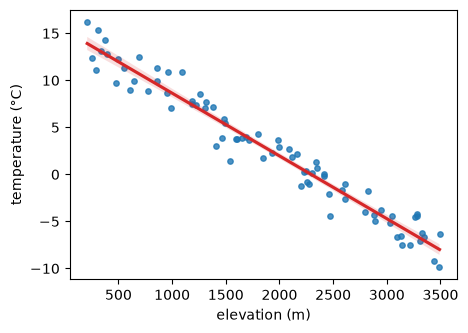

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
n = 80
elevation_m = rng.uniform(200, 3500, n)
temp_celsius = 15.0 - 6.5 * (elevation_m / 1000) + rng.normal(0, 1.5, n)
snow_days = 20 + 0.02 * elevation_m + rng.normal(0, 10, n)
df = pd.DataFrame({"elevation_m": elevation_m, "temp_celsius": temp_celsius, "snow_days": snow_days})

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.regplot(data=df, x="elevation_m", y="temp_celsius", ax=ax,
            scatter_kws={"s": 15}, line_kws={"color": "tab:red"})
ax.set_xlabel("elevation (m)")
ax.set_ylabel("temperature (°C)")
plt.show()

## Histograms, KDE, and Density Plots

A histogram counts observations into bins; a kernel density estimate (KDE) smooths that count into a continuous curve. `sns.histplot` and `sns.kdeplot` take the same `data=`/`x=` arguments as the rest of seaborn, and `hue=` splits either one by a categorical column in a single call — no manual loop over groups needed. The examples below use real measurements of three penguin species from the Palmer Archipelago, Antarctica (Horst, Hill & Gorman, 2020; *palmerpenguins*, doi:10.5281/zenodo.3960218; data collected by the Palmer Station Antarctica LTER and K. Gorman).

In [2]:
# Pre-supplied: download the data file and cache it locally.
# You do not need to understand this cell yet — fetching data is covered in the
# reproducible-data-pipelines bonus subchapter.
import pooch

penguins_path = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/palmer_penguins.csv",
    known_hash="sha256:f204db2c753b0937caac3cb35258562c14f073e4bbc76be24b4c51ce22767a93",
    fname="palmer_penguins.csv",
    path=pooch.os_cache("mlees"),
)

penguins = pd.read_csv(penguins_path).dropna(
    subset=["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
).reset_index(drop=True)

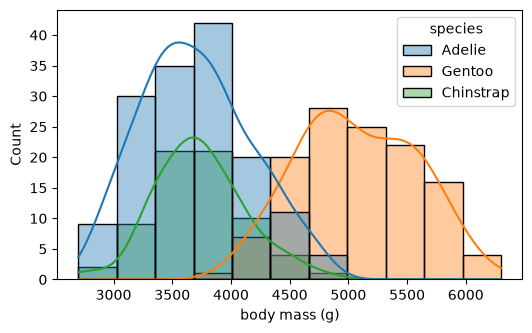

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.histplot(data=penguins, x="body_mass_g", hue="species", kde=True, ax=ax, alpha=0.4)
ax.set_xlabel("body mass (g)")
plt.show()

`kdeplot` also works on two variables at once, showing where two measurements co-vary rather than just their individual spreads; `jointplot` adds the two 1D marginal densities for free.

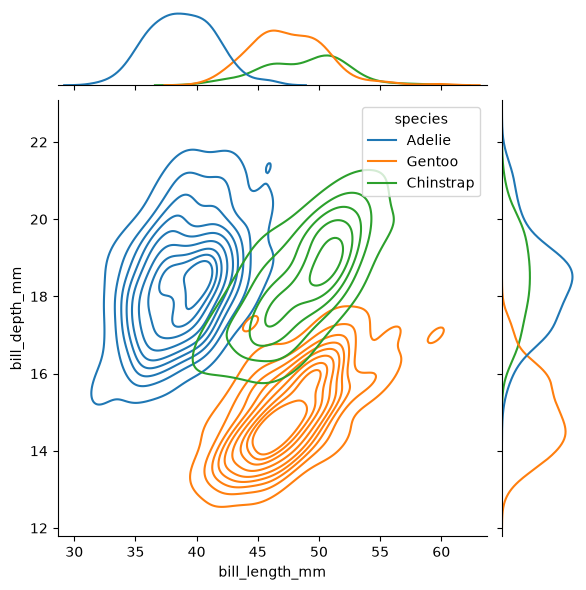

In [4]:
sns.jointplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species", kind="kde")

## Descriptive Statistics and Correlation

`describe` summarises each column; `corr` gives the pairwise Pearson correlation. Temperature is strongly anti-correlated with elevation — the lapse rate — while snow days rise with it.

       elevation_m  temp_celsius  snow_days
count        80.00         80.00      80.00
mean       1894.42          2.67      56.92
std         978.78          6.68      21.61
min         209.04         -9.87       6.52
25%        1161.85         -2.89      40.06
50%        1960.25          2.51      57.56
75%        2655.25          8.02      72.30
max        3490.79         16.17      99.78


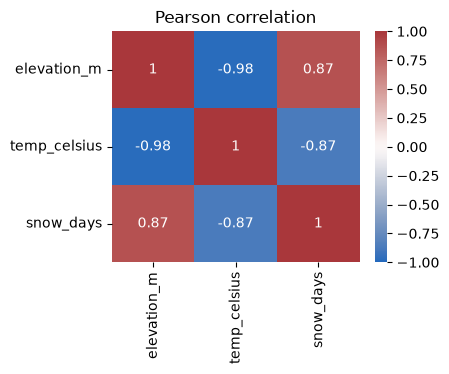

In [5]:
print(df.describe().round(2))

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(df.corr().round(2), annot=True, cmap="vlag", vmin=-1, vmax=1, ax=ax)
ax.set_title("Pearson correlation")
plt.show()

## The scikit-learn Estimator Interface

Every scikit-learn model is an object used the same way: instantiate it, `fit` it to a feature matrix `X` and target vector `y`, then `predict`. By convention `X` is two-dimensional with shape (n_samples, n_features) and `y` is one-dimensional. The fitted parameters are stored on attributes ending in an underscore.

In [6]:
from sklearn.linear_model import LinearRegression

X = df[["elevation_m"]]     # 2D feature matrix (note the double brackets)
y = df["temp_celsius"]      # 1D target

model = LinearRegression().fit(X, y)
lapse_rate = model.coef_[0] * 1000          # °C per km
print("recovered lapse rate:", round(lapse_rate, 2), "°C km^-1")
print("intercept (sea-level temp):", round(model.intercept_, 2), "°C")
print("prediction at 2000 m:", round(model.predict(pd.DataFrame({"elevation_m": [2000]}))[0], 2), "°C")

recovered lapse rate: -6.67 °C km^-1
intercept (sea-level temp): 15.31 °C
prediction at 2000 m: 1.96 °C


## Train/Test Split, RMSE, and R^2

A model must be judged on data it has not seen. `train_test_split` holds out a test set; the root-mean-square error (RMSE) reports the typical error in the target's units, and R^2 the fraction of variance explained.

test RMSE: 1.595 °C
test R^2:  0.947


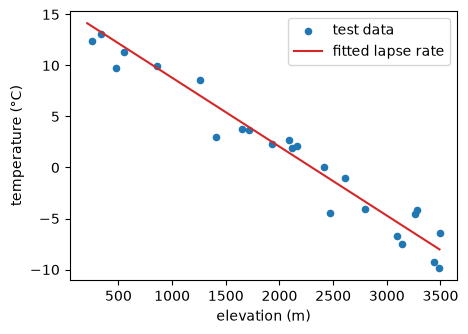

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

print("test RMSE:", round(root_mean_squared_error(y_test, y_pred), 3), "°C")
print("test R^2: ", round(r2_score(y_test, y_pred), 3))

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.scatter(X_test["elevation_m"], y_test, s=20, label="test data")
grid = pd.DataFrame({"elevation_m": np.linspace(X["elevation_m"].min(), X["elevation_m"].max(), 100)})
ax.plot(grid["elevation_m"], model.predict(grid), color="tab:red", label="fitted lapse rate")
ax.set_xlabel("elevation (m)")
ax.set_ylabel("temperature (°C)")
ax.legend()
plt.show()

:::{admonition} Computational-thinking fundamental: evaluate on data the model has not seen
:class: important
The goal of a model is to generalise, so its performance is what it achieves on unseen data — never on the data it was fitted to. A sufficiently flexible model can fit any training set perfectly, including its noise, while predicting new points badly. The train/test split (and, better, cross-validation) exists to measure generalisation rather than memorisation. A model scored only on its training data can report an R^2 near 1.0 and still be badly wrong on the very next new point it sees.
:::

## Scaling and Pipelines

Many estimators (regularised regressions, distance-based methods) require features on comparable scales; `StandardScaler` centres and scales them. A `Pipeline` chains preprocessing and model into one estimator, so the scaler is fitted on the training data only — which is exactly what prevents information from the test set leaking into training.

In [8]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pipe = make_pipeline(StandardScaler(), LinearRegression())
pipe.fit(X_train, y_train)
print("pipeline test R^2:", round(pipe.score(X_test, y_test), 3))
# for ordinary least squares, scaling leaves predictions unchanged; the habit matters
# for regularised and distance-based models, where unscaled features distort the fit

pipeline test R^2: 0.947


## Linear Classification

Not every target is continuous. When `y` is a category — here, whether a station's reading fell below freezing — a classifier follows the identical `fit`/`predict` interface. `LogisticRegression` is the classification analogue of linear regression: it fits a linear boundary in feature space and reports class probabilities rather than a continuous value.

In [9]:
from sklearn.linear_model import LogisticRegression

df["frost"] = (df["temp_celsius"] < 0.0).astype(int)
X_clf, y_clf = df[["elevation_m"]], df["frost"]
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_clf, y_clf, test_size=0.3, random_state=0)

clf = LogisticRegression().fit(Xc_train, yc_train)
print("test accuracy:", round(clf.score(Xc_test, yc_test), 3))
print("predicted frost at 3000 m:", bool(clf.predict(pd.DataFrame({"elevation_m": [3000]}))[0]))

test accuracy: 0.958
predicted frost at 3000 m: True


## Unsupervised Learning: Clustering and Dimensionality Reduction

Every model so far had a known target. Two more scikit-learn estimators follow the same `fit`/`predict` shape with no target at all: `KMeans` groups similar observations, and `PCA` finds the directions of greatest variance in correlated features. Both are demonstrated on the penguin measurements loaded above.

### k-means clustering

`KMeans` partitions points into `n_clusters` groups by repeatedly assigning each point to the nearest centroid and moving each centroid to the mean of its group. It has no notion of species — it only sees two physical measurements.

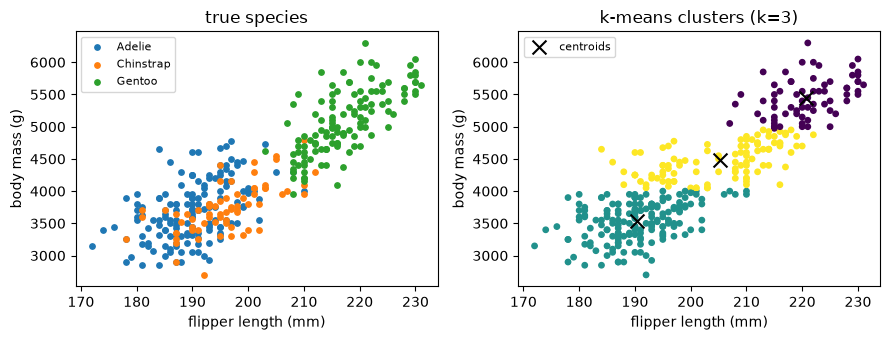

cluster     0    1   2
species               
Adelie      0  116  35
Chinstrap   0   53  15
Gentoo     68    1  54


In [10]:
from sklearn.cluster import KMeans

X_cluster = penguins[["flipper_length_mm", "body_mass_g"]]
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10).fit(X_cluster)
penguins["cluster"] = kmeans.labels_

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for species, group in penguins.groupby("species"):
    axes[0].scatter(group["flipper_length_mm"], group["body_mass_g"], s=15, label=species)
axes[0].set_title("true species")
axes[0].legend(fontsize=8)

axes[1].scatter(X_cluster["flipper_length_mm"], X_cluster["body_mass_g"],
                c=penguins["cluster"], s=15, cmap="viridis")
axes[1].scatter(*kmeans.cluster_centers_.T, marker="x", s=100, color="black", label="centroids")
axes[1].set_title("k-means clusters (k=3)")
axes[1].legend(fontsize=8)
for ax in axes:
    ax.set_xlabel("flipper length (mm)")
    ax.set_ylabel("body mass (g)")
plt.tight_layout()
plt.show()

# crosstab counts how many of each true species fall into each cluster
print(pd.crosstab(penguins["species"], penguins["cluster"]))

Two features are not quite enough to cleanly separate three species by shape alone: Gentoo (heavier, longer-flippered) forms its own cluster, but Adelie and Chinstrap overlap and mix into the other two clusters — the crosstab shows exactly where. Clustering finds structure in the *features you give it*; it cannot recover a label the features do not distinguish.

### Choosing k: the elbow method

We fixed `k=3` because we already know there are three species — in general the right number of clusters is not known in advance. The elbow method refits `KMeans` across a range of `k` and plots the inertia (each point's squared distance to its cluster's centroid, summed over every point): inertia always falls as `k` grows, but the rate of improvement drops sharply once extra clusters stop capturing real structure — a bend, or "elbow", in the curve.

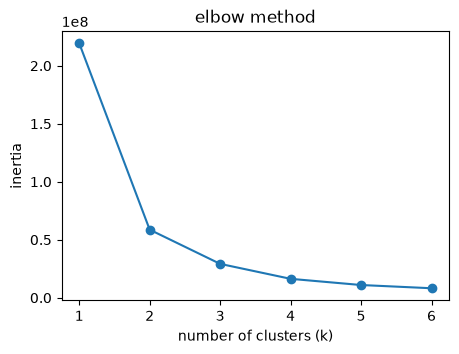

In [11]:
inertias = []
k_values = range(1, 7)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=0, n_init=10).fit(X_cluster)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(list(k_values), inertias, marker="o")
ax.set_xlabel("number of clusters (k)")
ax.set_ylabel("inertia")
ax.set_title("elbow method")
plt.show()

# sklearn.metrics.silhouette_score is a complementary diagnostic: it scores how
# well-separated the clusters are, without needing a visual bend to read

### Dimensionality reduction with PCA

`PCA` finds new axes — linear combinations of the original features — ordered by how much variance they capture, so a handful of components can summarise many correlated measurements. Scale first, exactly as for the pipeline above: PCA is sensitive to each feature's variance, not just its values.

explained variance ratio: [0.688 0.193]


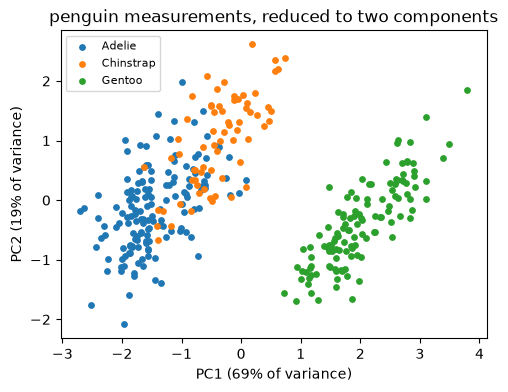

In [12]:
from sklearn.decomposition import PCA

features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
Xs = StandardScaler().fit_transform(penguins[features])

pca = PCA(n_components=2).fit(Xs)
scores = pca.transform(Xs)
penguins["pc1"], penguins["pc2"] = scores[:, 0], scores[:, 1]
print("explained variance ratio:", pca.explained_variance_ratio_.round(3))

fig, ax = plt.subplots(figsize=(5.5, 4))
for species, group in penguins.groupby("species"):
    ax.scatter(group["pc1"], group["pc2"], s=15, label=species)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} of variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} of variance)")
ax.set_title("penguin measurements, reduced to two components")
ax.legend(fontsize=8)
plt.show()

Unlike k-means, PCA needs no target and no assumed number of groups — here the first two components already separate the three species almost as cleanly as the full four-feature space, using all four correlated measurements at once instead of picking two by hand.

## *When generated code lies: scoring on the training data*

Asked to "evaluate the model", an assistant fits a flexible model and reports R^2 on the same data it trained on. On a small, noisy sample a high-degree polynomial fits almost perfectly — and predicts new points disastrously.

In [13]:
from sklearn.preprocessing import PolynomialFeatures

rng2 = np.random.default_rng(1)
x_small = np.linspace(0.2, 3.5, 20)
y_small = 15.0 - 6.5 * x_small + rng2.normal(0, 2.0, 20)   # noisy lapse rate, km
Xs = x_small.reshape(-1, 1)
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(Xs, y_small, test_size=0.4, random_state=0)

overfit = make_pipeline(PolynomialFeatures(degree=8), LinearRegression()).fit(Xs_tr, ys_tr)
print("degree-8 R^2 on TRAINING data:", round(r2_score(ys_tr, overfit.predict(Xs_tr)), 3))

degree-8 R^2 on TRAINING data: 0.971


:::{admonition} Diagnosis: a training score is not performance
:class: warning
The training R^2 near 1.0 only shows that the degree-8 polynomial curve passes close to its own training points — with eight free coefficients it bent to match the noise in that particular sample rather than the underlying trend. Evaluated on held-out data the same model is catastrophic, while the simple linear model — the correct physical form — generalises well. Only the test score reflects how the model performs on data it has not seen.
:::

In [14]:
linear = LinearRegression().fit(Xs_tr, ys_tr)
print("degree-8 R^2 on TEST data:", round(r2_score(ys_te, overfit.predict(Xs_te)), 1))
print("linear    R^2 on TEST data:", round(r2_score(ys_te, linear.predict(Xs_te)), 3))

degree-8 R^2 on TEST data: -7.1
linear    R^2 on TEST data: 0.984


:::{admonition} Quick exercise: recover the lapse rate honestly
:class: note
Split the `df` data into train and test, fit a `LinearRegression` of `temp_celsius` on `elevation_m`, and report the recovered lapse rate (°C km⁻¹) and the test R^2.
:::

:::{admonition} Solution
:class: note dropdown
```python
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
X = df[["elevation_m"]]; y = df["temp_celsius"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)
m = LinearRegression().fit(Xtr, ytr)
print(round(m.coef_[0] * 1000, 2), "°C km^-1")
print(round(r2_score(yte, m.predict(Xte)), 3))
```
:::

:::{admonition} Going deeper: cross-validation
:class: seealso dropdown
A single split is noisy. k-fold cross-validation rotates the held-out fold and averages, giving a more stable estimate of generalisation.

```python
from sklearn.model_selection import cross_val_score
scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2")
print(scores.mean(), scores.std())
```
:::

:::{admonition} Going deeper: beyond a linear decision boundary
:class: seealso dropdown
`LogisticRegression` only draws a straight (or, with more features, flat) boundary. k-nearest neighbours and a decision tree follow the same interface but can bend around more complex class shapes.

```python
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

knn = KNeighborsClassifier(n_neighbors=5).fit(Xc_train, yc_train)
tree = DecisionTreeClassifier(max_depth=3).fit(Xc_train, yc_train)
```

Swapping one estimator for another only changes the one line that creates the model — the rest of the pipeline stays the same.
:::

:::{admonition} Going deeper: faceted histograms
:class: seealso dropdown
`sns.displot` repeats one plot across the levels of a categorical column, so several distributions compare at a glance, on shared axes.
:::

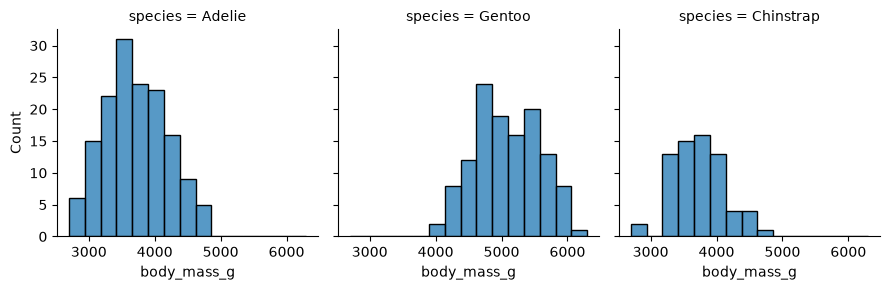

In [15]:
sns.displot(data=penguins, x="body_mass_g", col="species", bins=15, height=3)

:::{admonition} Going deeper: boxplots
:class: seealso dropdown
A boxplot summarises a distribution's median, quartiles, and outliers per category — more compact than a histogram when comparing several groups at once.
:::

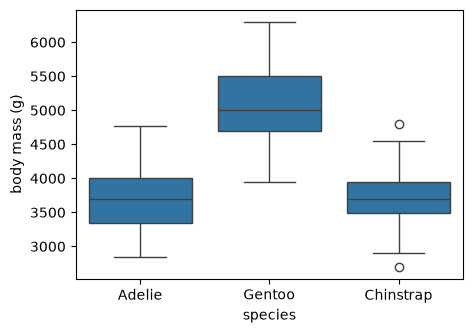

In [16]:
fig, ax = plt.subplots(figsize=(5, 3.5))
sns.boxplot(data=penguins, x="species", y="body_mass_g", ax=ax)
ax.set_ylabel("body mass (g)")
plt.show()

:::{admonition} Going deeper: bar plots
:class: seealso dropdown
`sns.barplot` aggregates a numeric column per category (the mean, by default) and draws the result with an error bar — a quick alternative to a manual `groupby` and hand-drawn bar chart.
:::

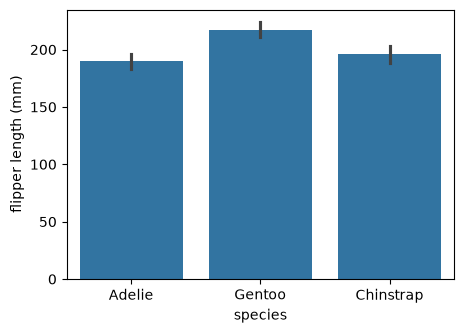

In [17]:
fig, ax = plt.subplots(figsize=(5, 3.5))
sns.barplot(data=penguins, x="species", y="flipper_length_mm", ax=ax, errorbar="sd")
ax.set_ylabel("flipper length (mm)")
plt.show()

:::{admonition} Going deeper: inferential regression with statsmodels
:class: seealso dropdown
scikit-learn optimises prediction; `statsmodels` reports the inferential statistics — standard errors, confidence intervals, p-values — needed to reason about the lapse-rate estimate itself.

```python
import statsmodels.api as sm
result = sm.OLS(y, sm.add_constant(X)).fit()
print(result.summary())      # coefficients with standard errors and CIs
```
:::

:::{admonition} Going deeper: bootstrap confidence intervals
:class: seealso dropdown
Resampling the data with replacement and refitting many times gives an empirical distribution of any estimate — here the lapse rate — without distributional assumptions.

```python
slopes = []
for _ in range(1000):
    idx = rng.integers(0, len(X), len(X))
    slopes.append(LinearRegression().fit(X.iloc[idx], y.iloc[idx]).coef_[0] * 1000)
low, high = np.percentile(slopes, [2.5, 97.5])   # 95% interval
```
:::

:::{admonition} Takeaways
:class: danger
- Explore before modelling: seaborn plots, `describe`, and `corr` reveal structure and relationships; seaborn is a layer over matplotlib, and the two compose.
- `sns.histplot`/`sns.kdeplot` show a distribution (optionally split by `hue=`); `jointplot` adds two variables' 1D marginals around a 2D view.
- Every scikit-learn estimator follows instantiate → `fit(X, y)` → `predict`, with `X` two-dimensional and `y` one-dimensional.
- Fit on a training set and evaluate on a held-out test set; report RMSE (in target units) and R^2.
- A high training score with a low test score is overfitting — a training score alone is never performance.
- Use `StandardScaler` and a `Pipeline` so preprocessing is fitted on training data only, preventing leakage.
- `LogisticRegression` extends the same fit/predict interface to a categorical target.
- `KMeans` and `PCA` need no target: clustering groups by proximity, PCA summarises correlated features by variance; refit `KMeans` across a range of k and plot inertia (the elbow method) to choose k when it is not known in advance.
:::

## Resources

- [scikit-learn — Getting started](https://scikit-learn.org/stable/getting_started.html) — the estimator interface, fit/predict, train/test evaluation, and pipelines.
- [seaborn](https://seaborn.pydata.org/) — statistical visualisation on dataframes, including regression, correlation, and categorical plots (`displot`, `boxplot`, `barplot`).
- [scikit-learn — Clustering](https://scikit-learn.org/stable/modules/clustering.html) and [Decomposing signals (PCA)](https://scikit-learn.org/stable/modules/decomposition.html#pca) — the k-means and PCA reference documentation, including choosing k.
- [palmerpenguins](https://allisonhorst.github.io/palmerpenguins/) — Horst, Hill & Gorman (2020); the real dataset used for clustering and PCA above.